# Chunking Passes for Jackknives

The question is how to chunk data into as short temporal sequences as possible, while hitting a balance between sparse beam samples and being stupidly empty. All while decimating the passes by a factor of 5, to eliminate the worst of the correlation introduced by the SavGol filtering

In [ ]:
from pathlib import Path
from datetime import datetime, UTC
from collections.abc import Sequence

import numpy as np
import healpy as hp
import cmasher as cmr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

from embers_passes import PassFile, chunk_passes, chunks_to_healpix_counts, \
    healpix_to_pyuvdata

colors = cmr.pride(np.linspace(0.1, 0.8, 256))
colors[0] = mcolors.to_rgba("whitesmoke")
prd = ListedColormap(colors, name="pride")
prd.set_under("whitesmoke")

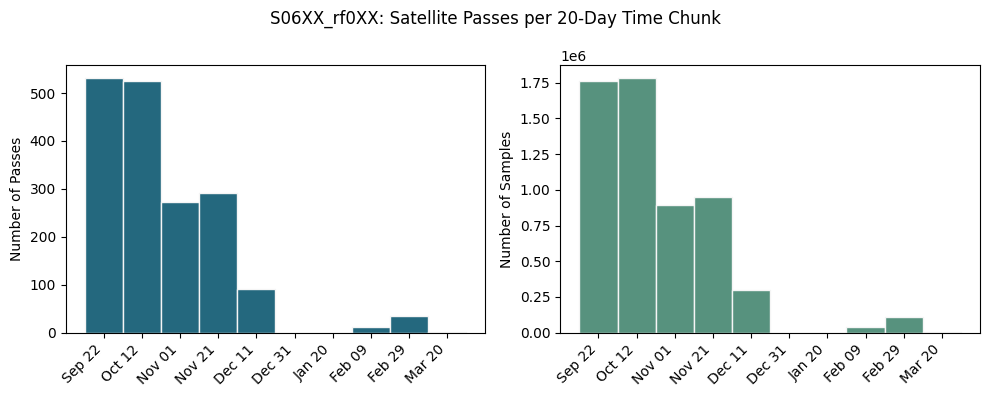

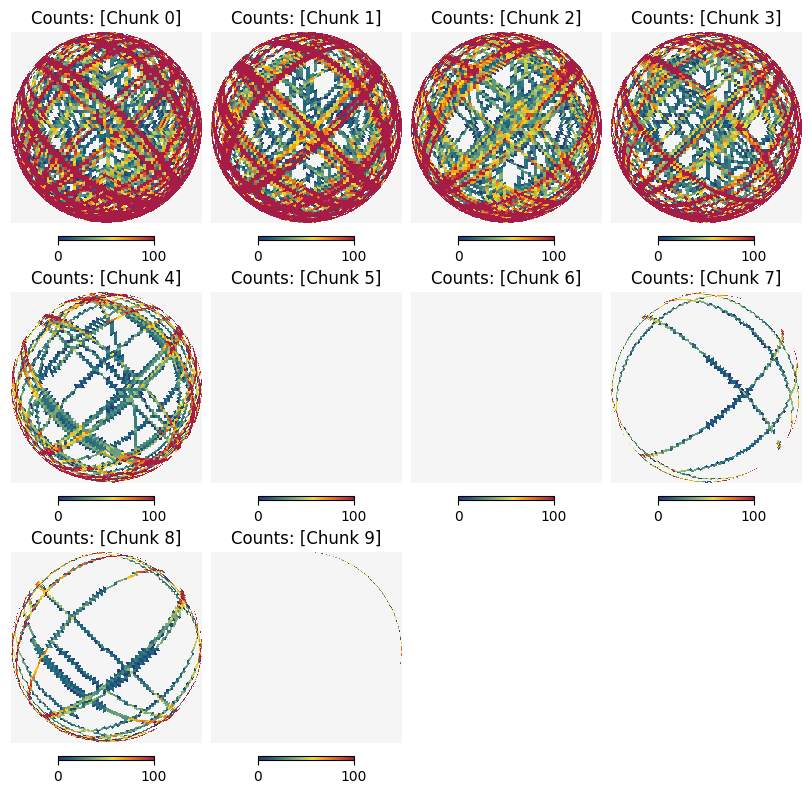

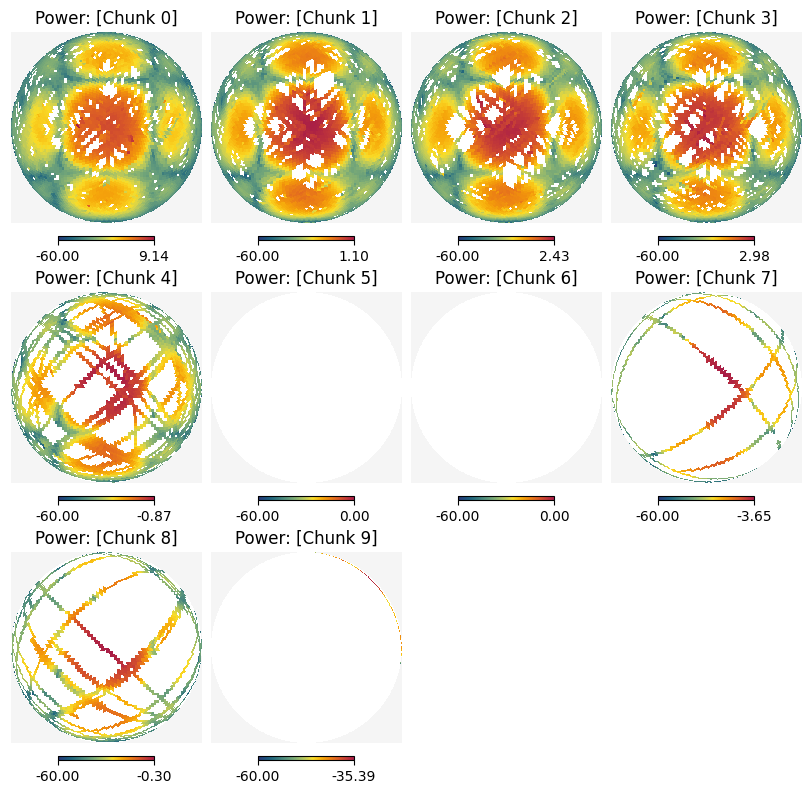

In [ ]:
S06XX_rf0XX = Path("../passes/monotonic_concave_5hz_pval/S06XX_rf0XX_passes.h5")
pf = PassFile(S06XX_rf0XX)
passes = pf.read_passes(pointing=0)

chunk_days = 20
chunk_sec = chunk_days * 24 * 60 * 60
chunks, bin_edges, bin_centers = chunk_passes(
    passes,
    chunk_sec=chunk_sec,
)

pass_counts = [len(chunk) for chunk in chunks]

sample_counts = [0]*len(chunks)
for i, chunk in enumerate(chunks):
    for cid in chunk:
        pass_n_samples = passes[cid].power_db.size
        sample_counts[i] += pass_n_samples

# Convert Unix timestamps to UTC datetimes
bin_center_dt = [
    datetime.fromtimestamp(t, tz=UTC)
    for t in bin_centers
]

median_maps, count_maps, mad_maps = chunks_to_healpix_counts(
    passes,
    chunks,
    decimate=1,
    nside=32,
)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].bar(
    bin_center_dt,
    pass_counts,
    width=chunk_days,
    align="center",
    color=cmr.pride(0.2),
    ec="whitesmoke"
)
ax[0].set_ylabel("Number of Passes")

ax[1].bar(
    bin_center_dt,
    sample_counts,
    width=chunk_days,
    align="center",
    color=cmr.pride(0.3),
    ec="whitesmoke"
)
ax[1].set_ylabel("Number of Samples")

labels = [dt.strftime("%b %d") for dt in bin_center_dt]
for a in ax:
    a.set_xticks(bin_center_dt)
    a.set_xticklabels(labels, rotation=45, ha="right")

fig.suptitle(f"{S06XX_rf0XX.stem[:11]}: Satellite Passes per {chunk_days}-Day Time Chunk")

plt.tight_layout()
plt.show()

ncols = 4
nrows = np.ceil(len(count_maps) / ncols)

fig = plt.figure(figsize=(2 * ncols, 2.6 * nrows))

for i, count_map in enumerate(count_maps):
    hp.orthview(
        count_map,
        fig=fig.number,
        sub=(nrows, ncols, i + 1),
        title=f"Counts: [Chunk {i}]",
        min=0,
        max=100,
        cmap=prd,
        cbar=True,
        half_sky=True,
        rot=(0, 90, 180)
    )

plt.show()

fig = plt.figure(figsize=(2 * ncols, 2.6 * nrows))

for i, median_map in enumerate(median_maps):
    hp.orthview(
        median_map,
        fig=fig.number,
        sub=(nrows, ncols, i + 1),
        title=f"Power: [Chunk {i}]",
        format="%.2f",
        min=-60,
        # max=100,
        cmap=prd,
        cbar=True,
        half_sky=True,
        rot=(0, 90, 180)
    )

plt.show()

## pyuvdata convention orthographic grid

In [6]:
median_values, za_rad_pyuvdata, az_rad_pyuvdata = healpix_to_pyuvdata(median_maps[0])

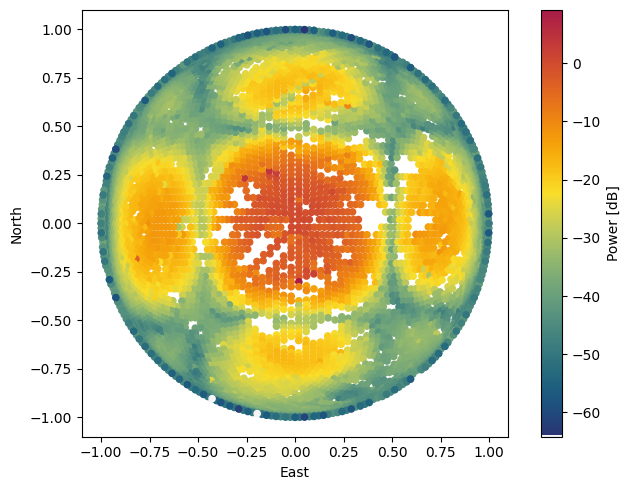

In [7]:
x = np.sin(za_rad_pyuvdata) * np.sin(az_rad_pyuvdata)  # East
y = np.sin(za_rad_pyuvdata) * np.cos(az_rad_pyuvdata)  # North

fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    x,
    y,
    c=median_values,
    s=20,
    cmap=prd,
)

ax.set_aspect("equal")
ax.set_xlabel("East")
ax.set_ylabel("North")

plt.colorbar(sc, ax=ax, label="Power [dB]")

plt.tight_layout()
plt.show()

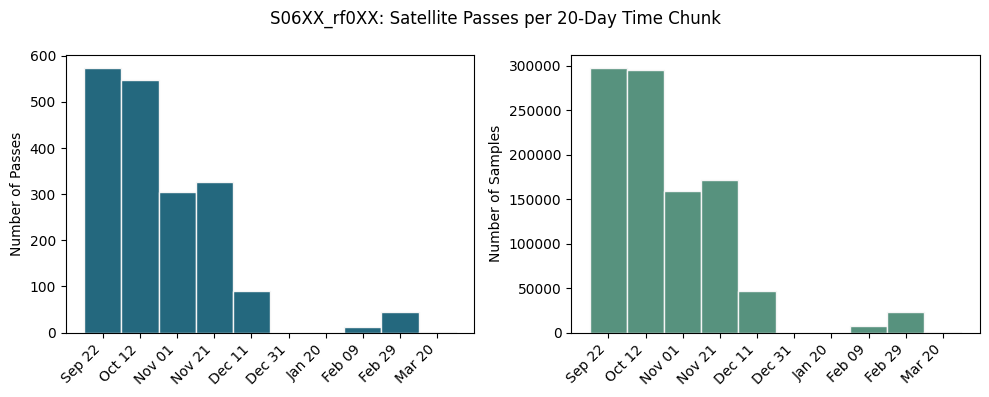

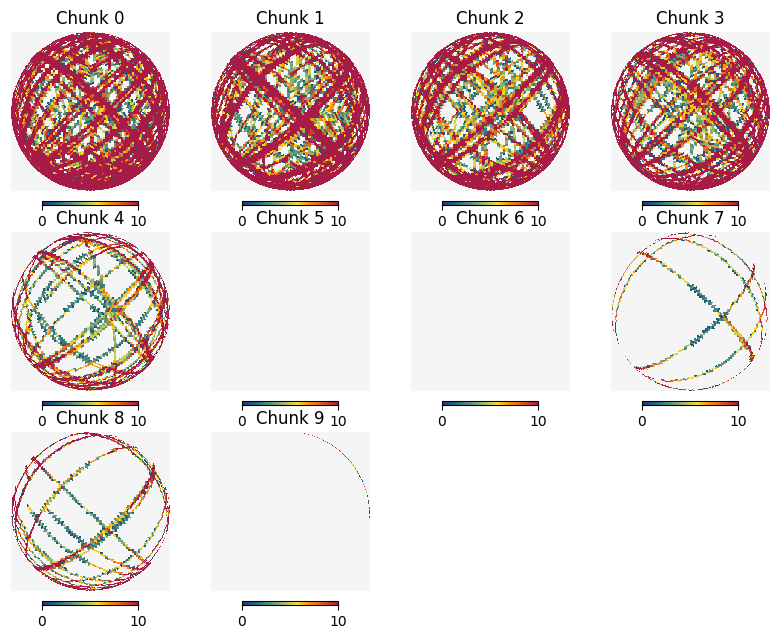

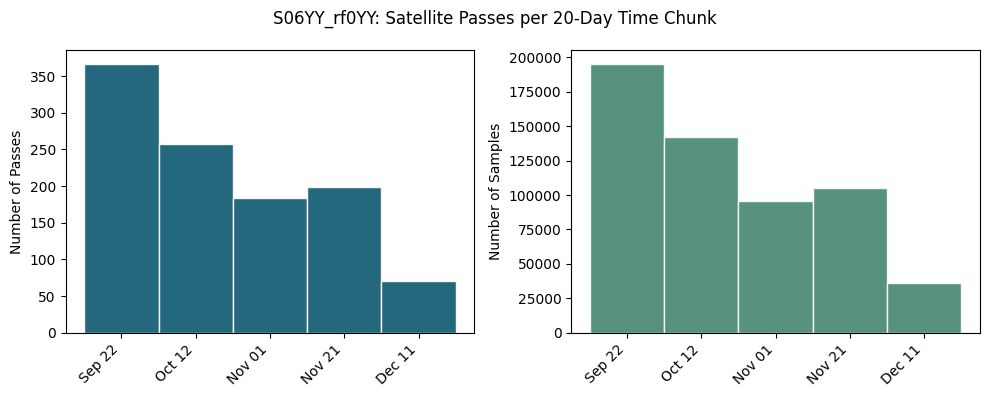

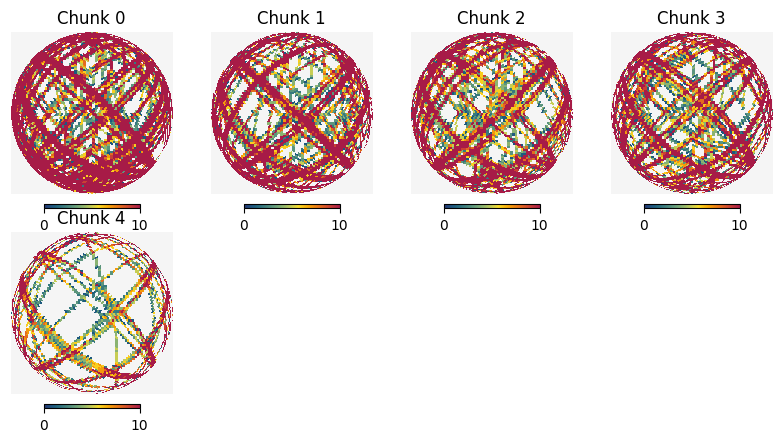

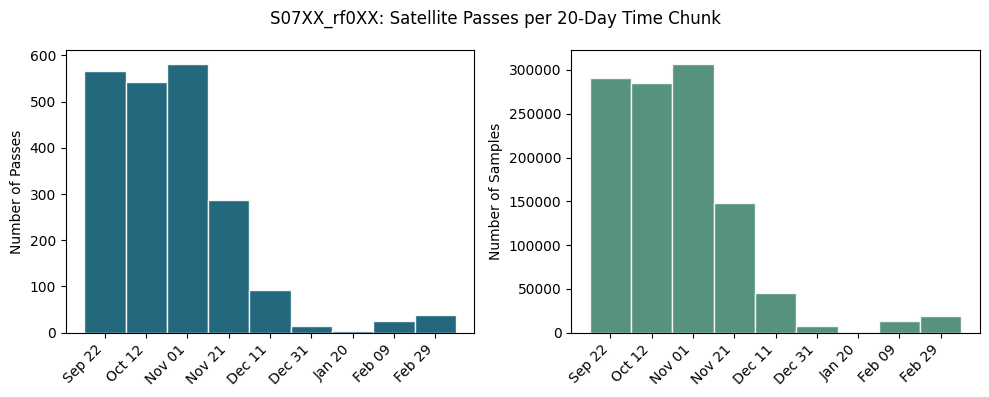

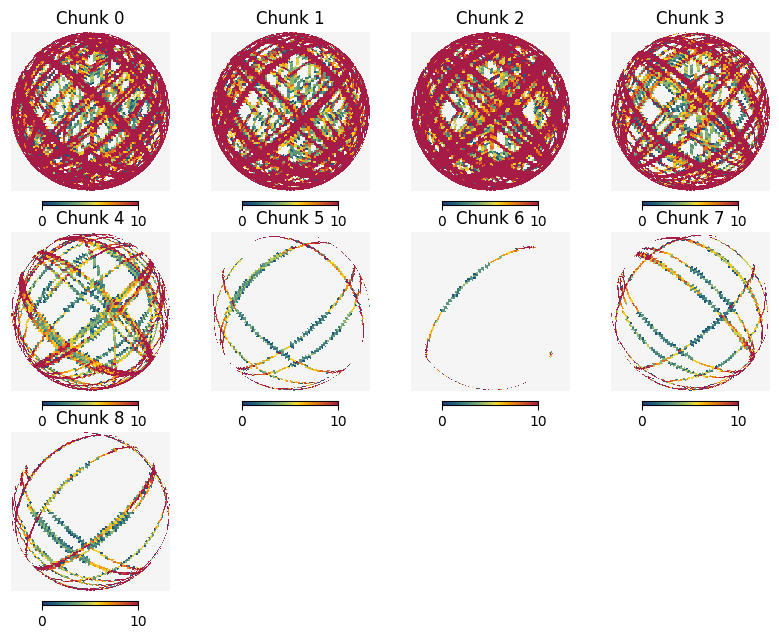

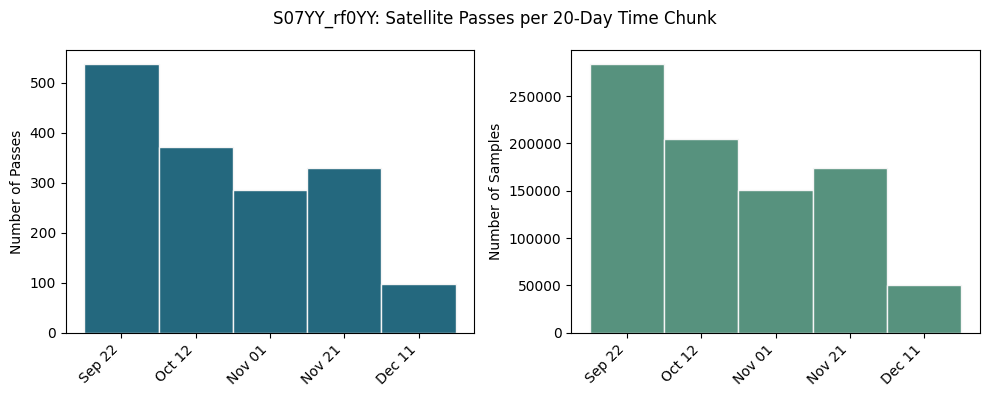

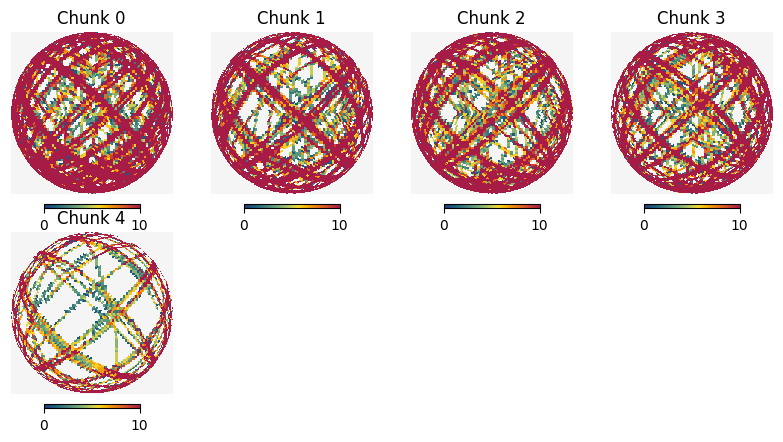

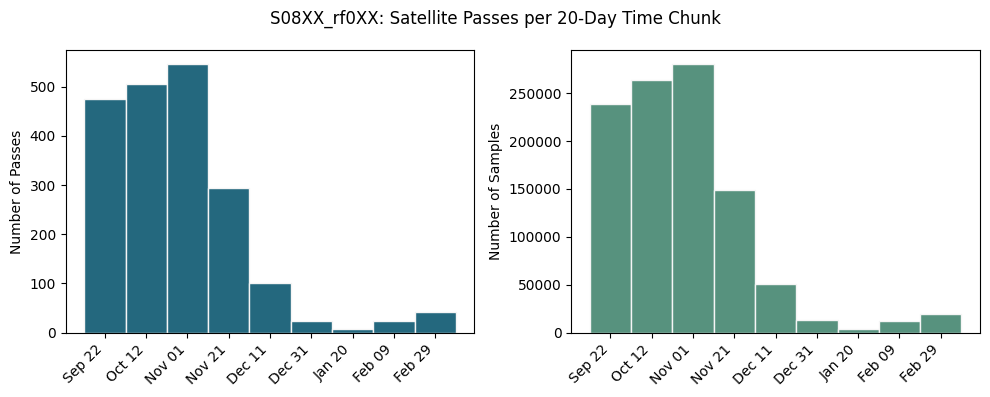

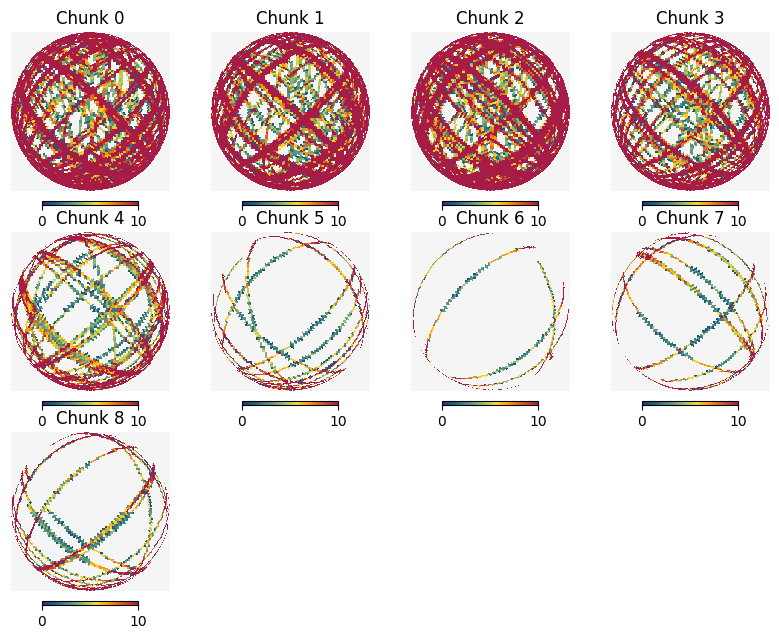

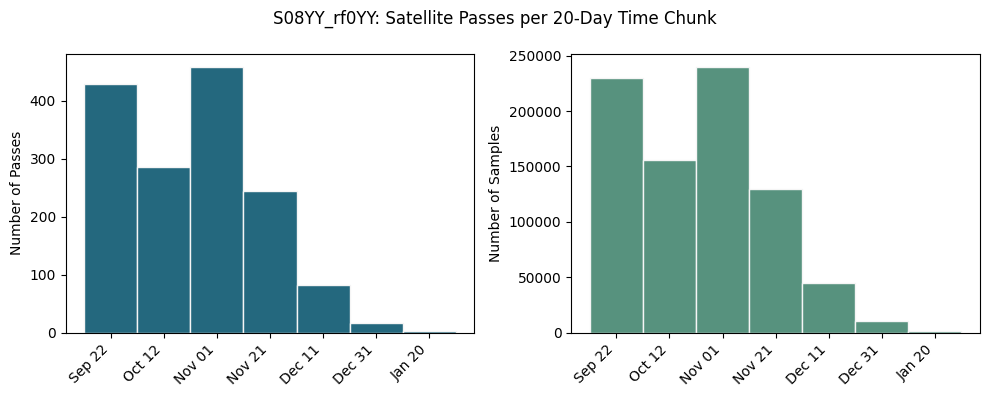

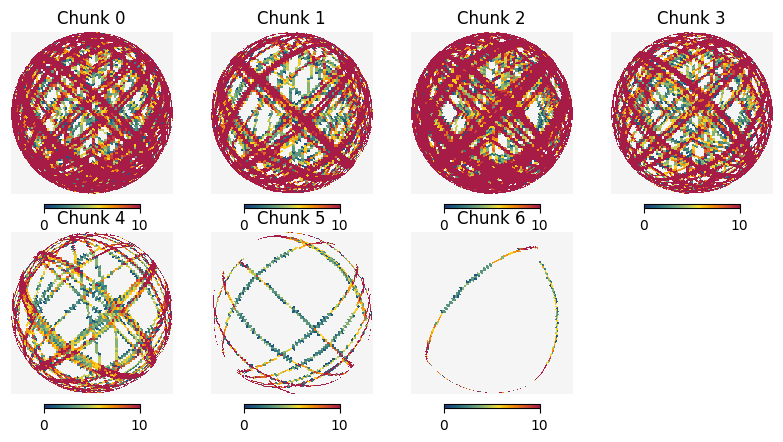

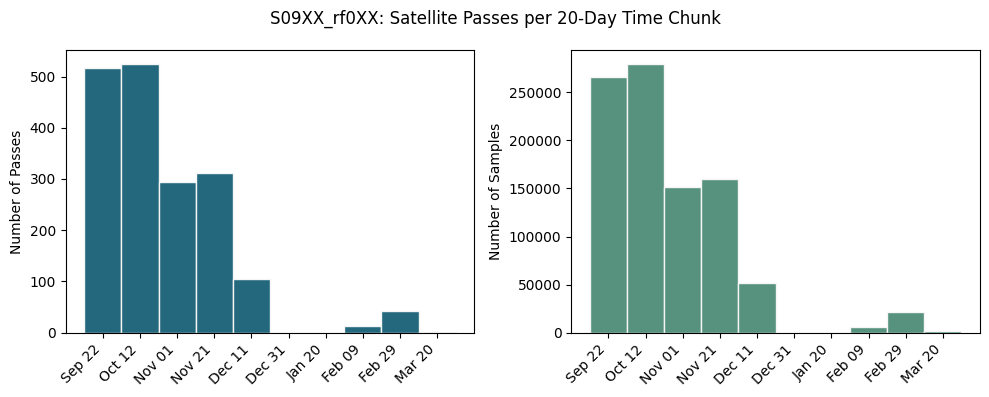

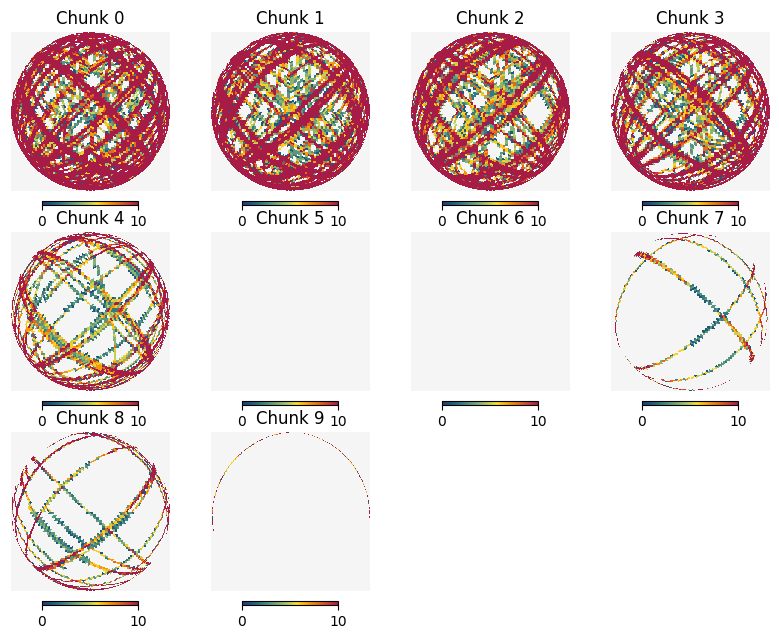

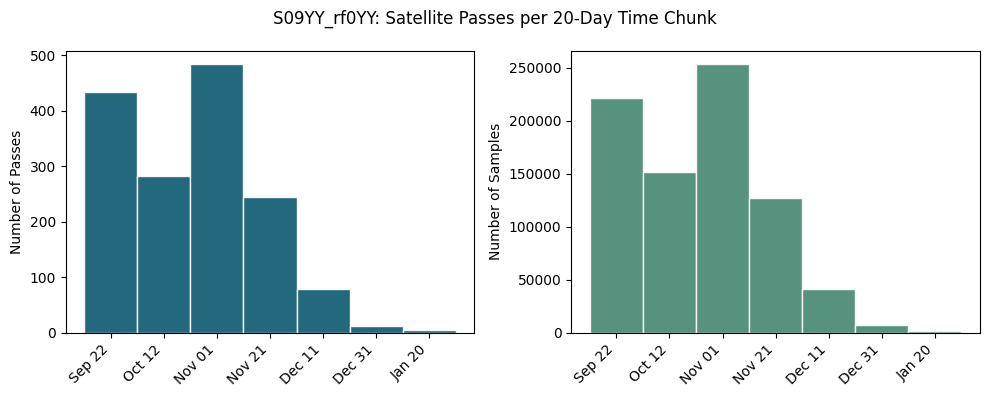

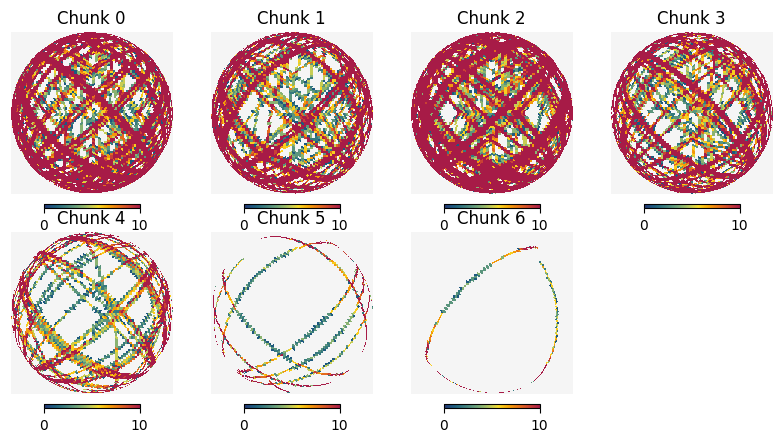

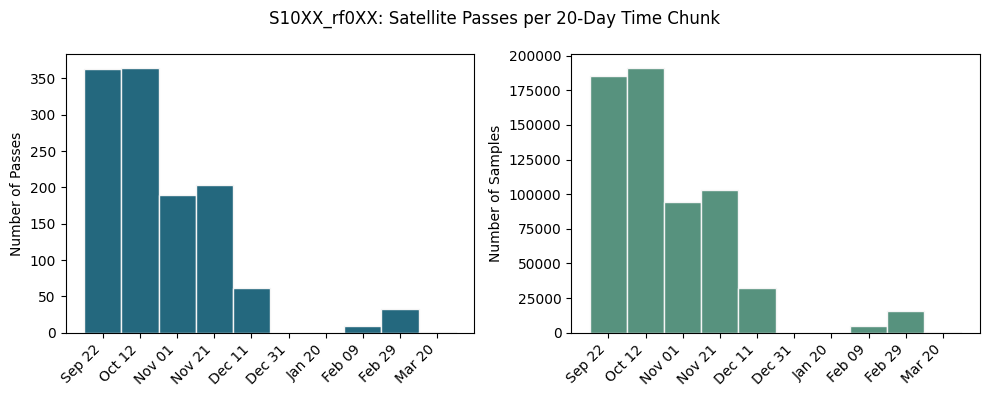

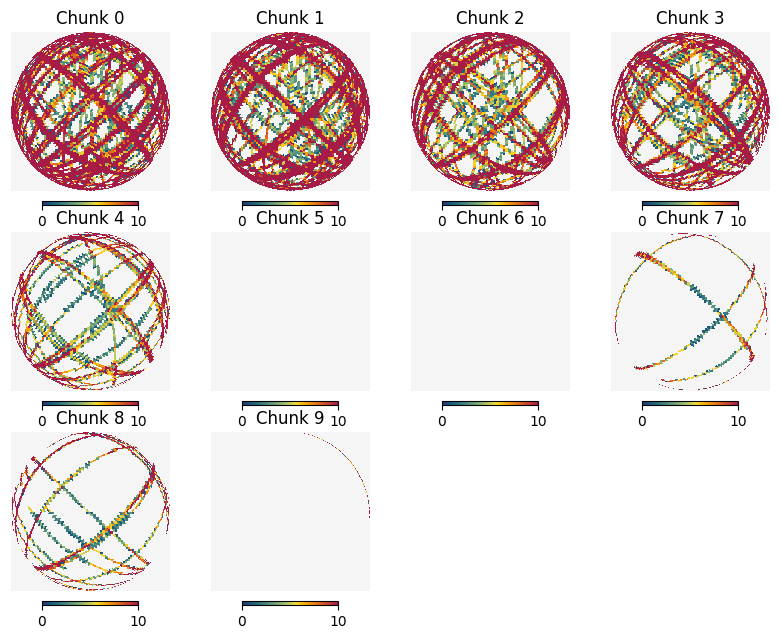

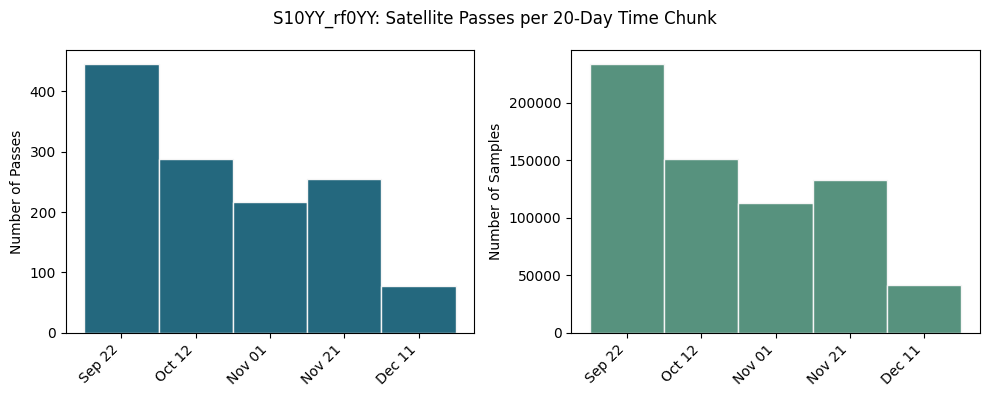

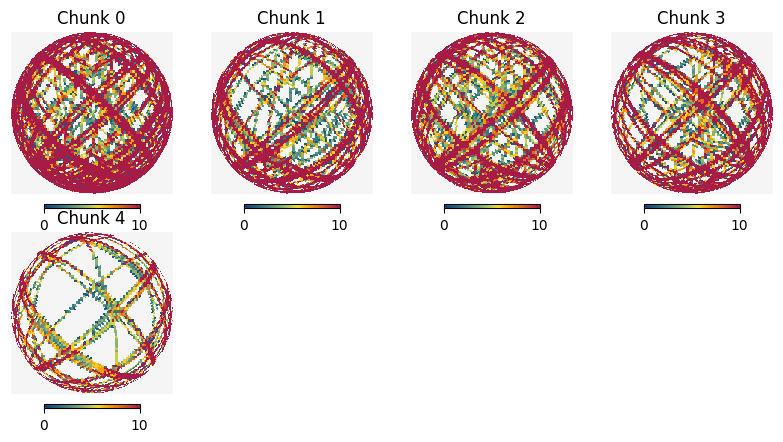

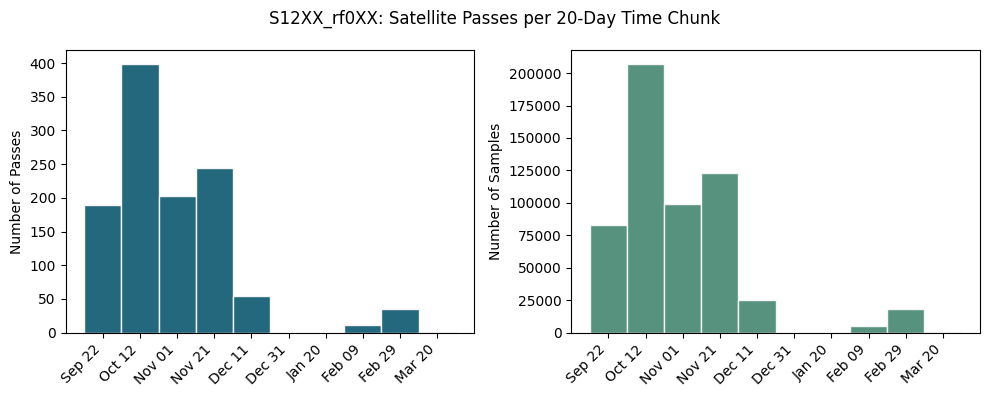

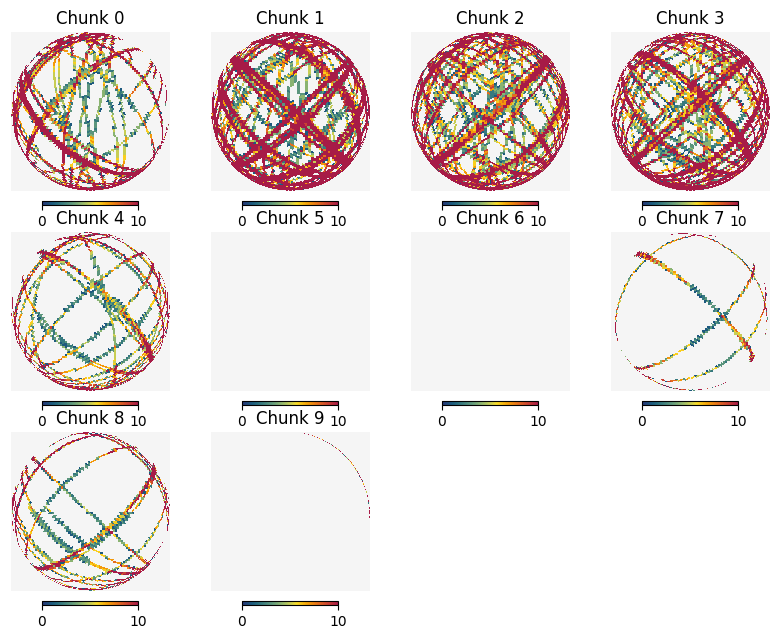

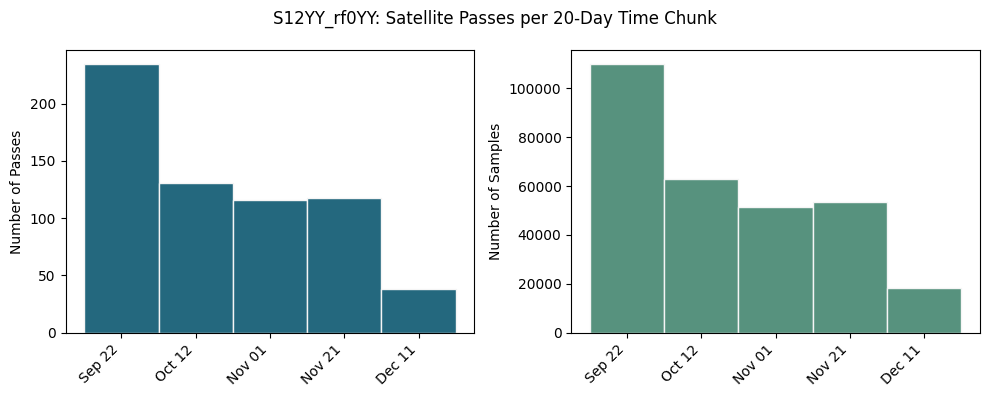

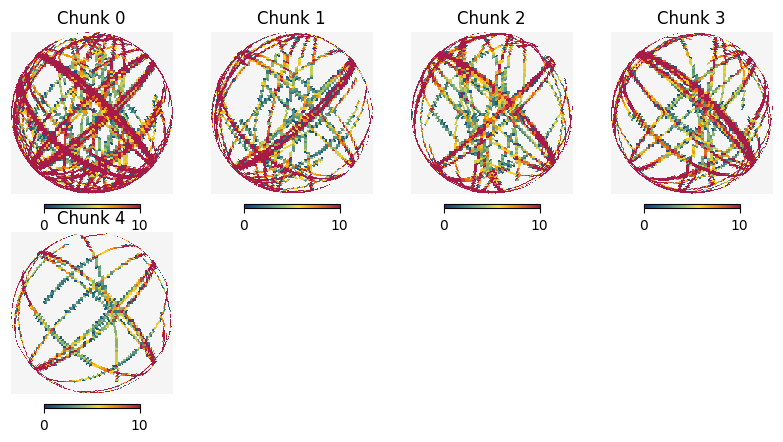

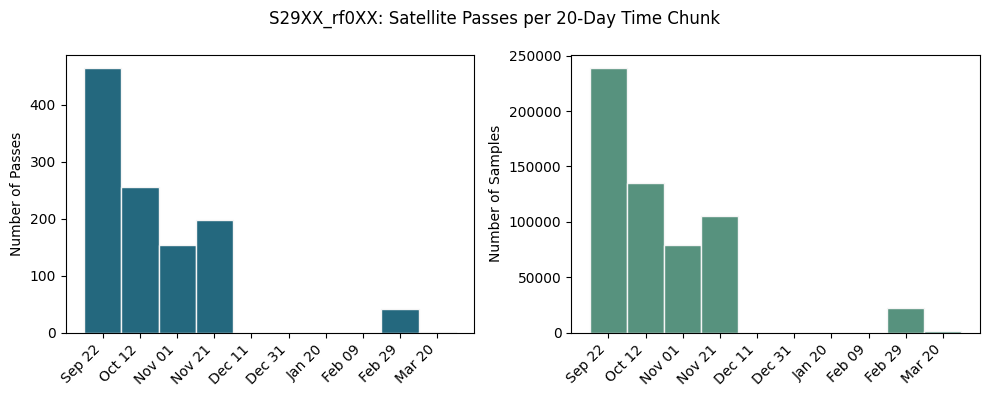

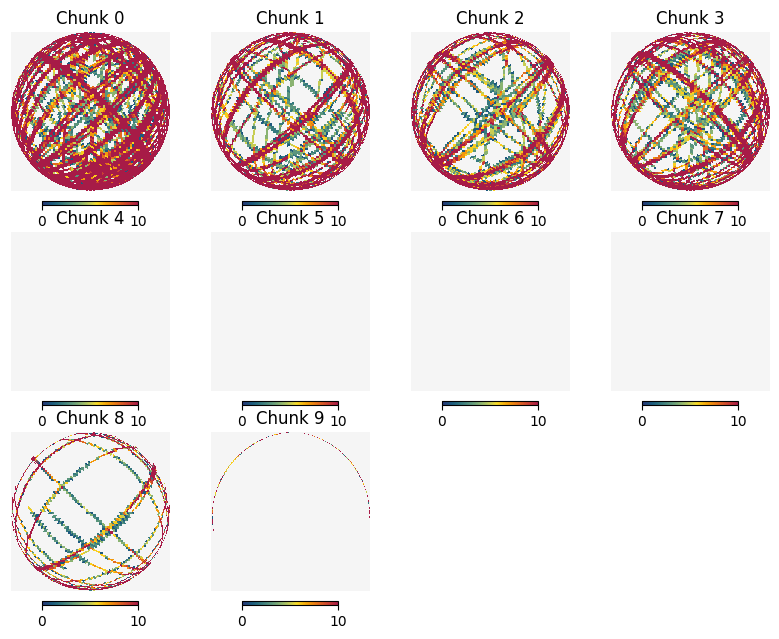

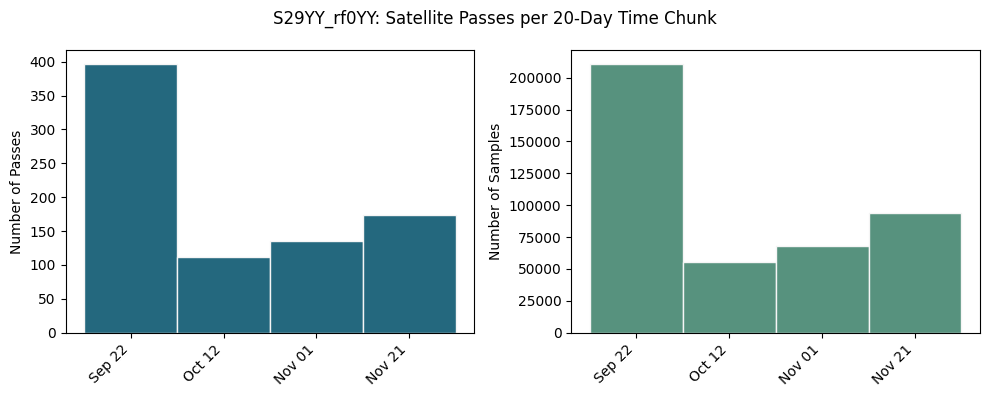

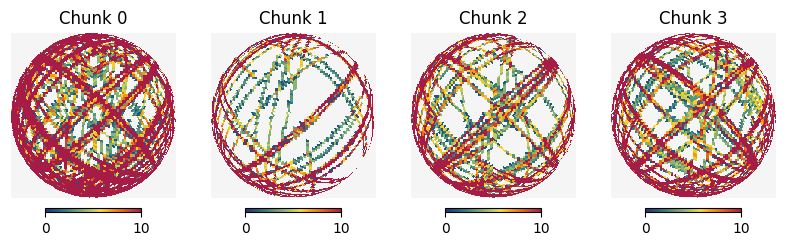

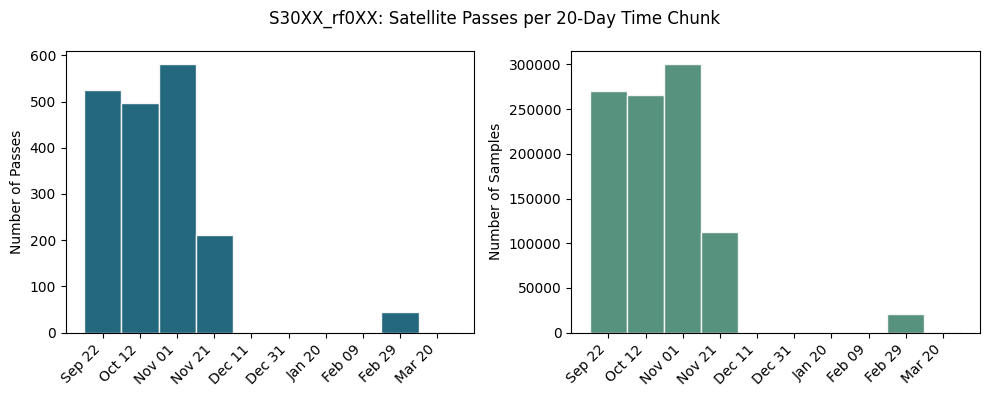

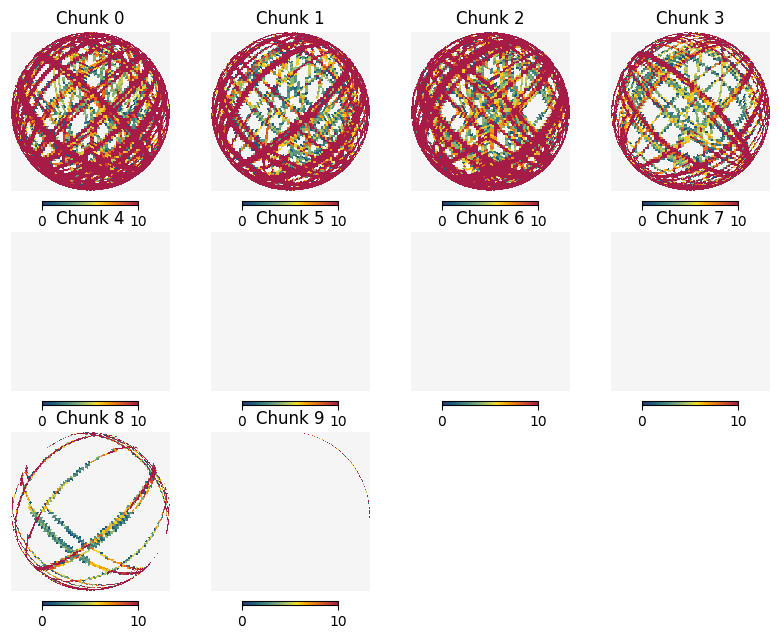

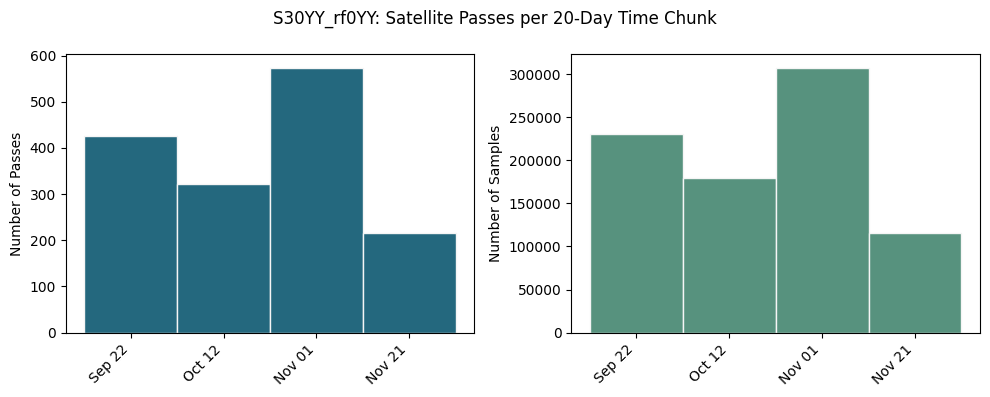

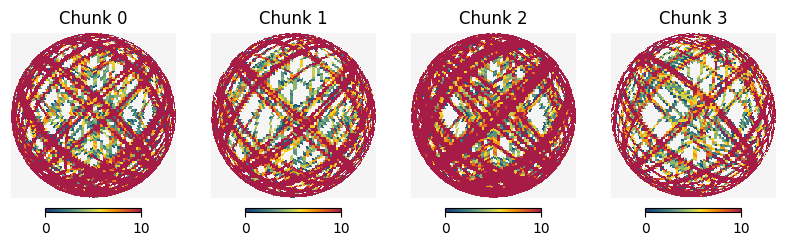

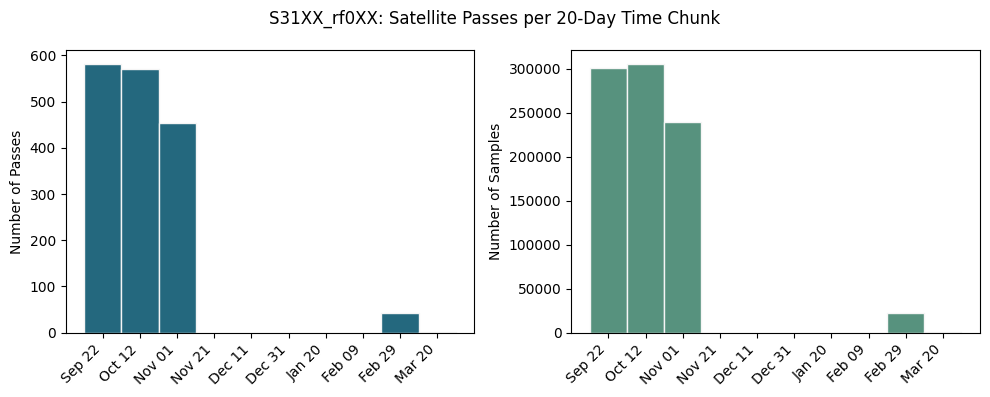

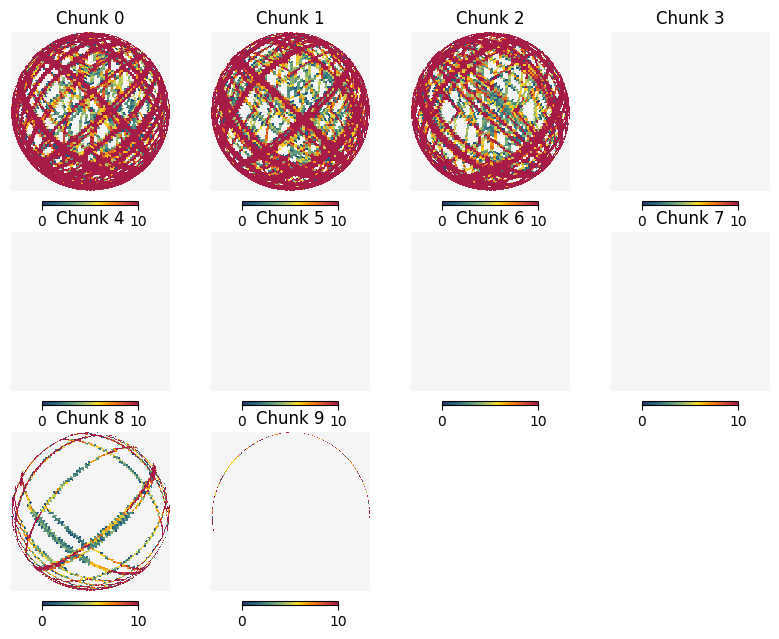

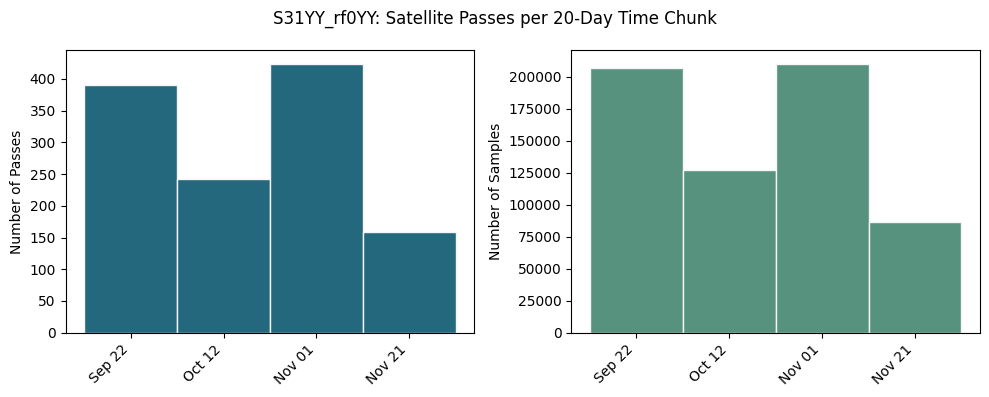

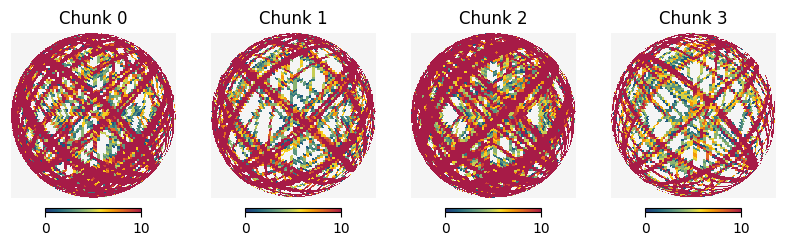

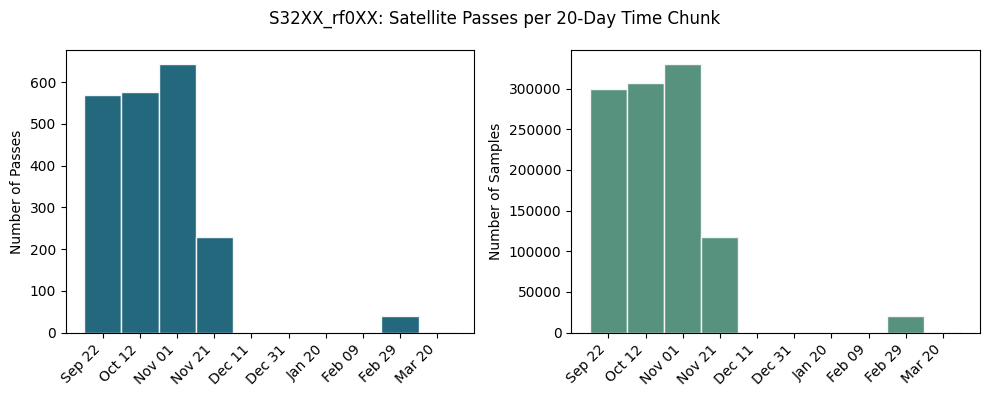

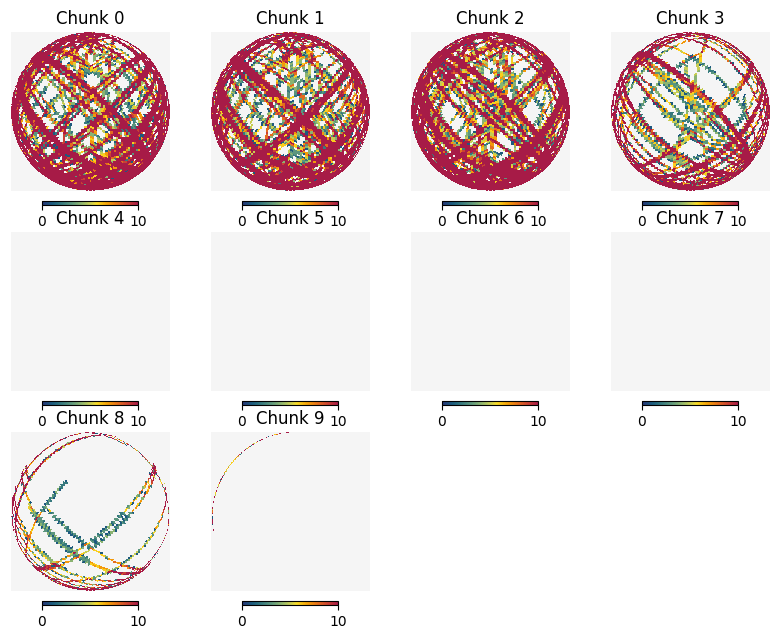

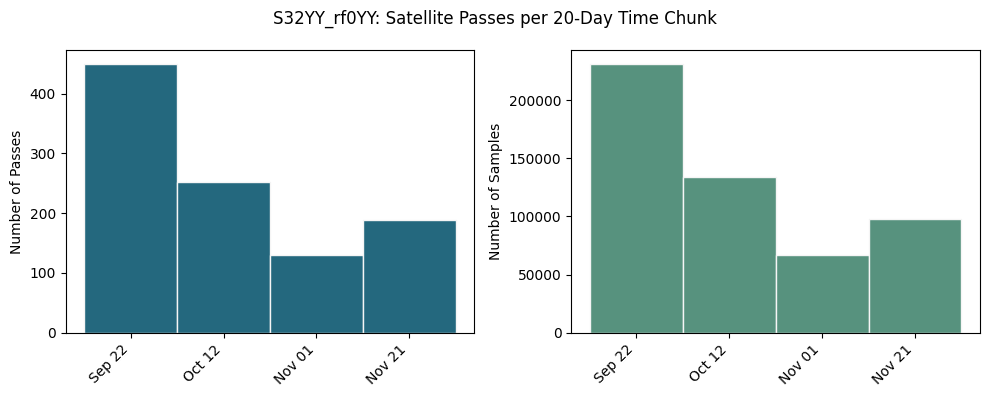

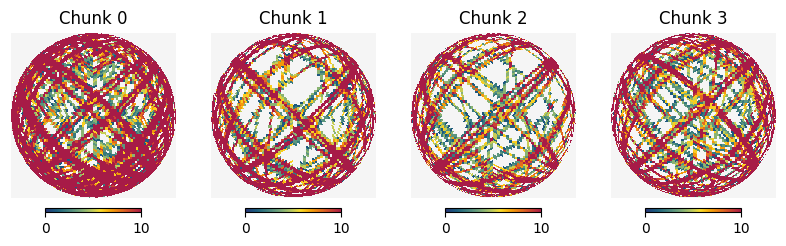

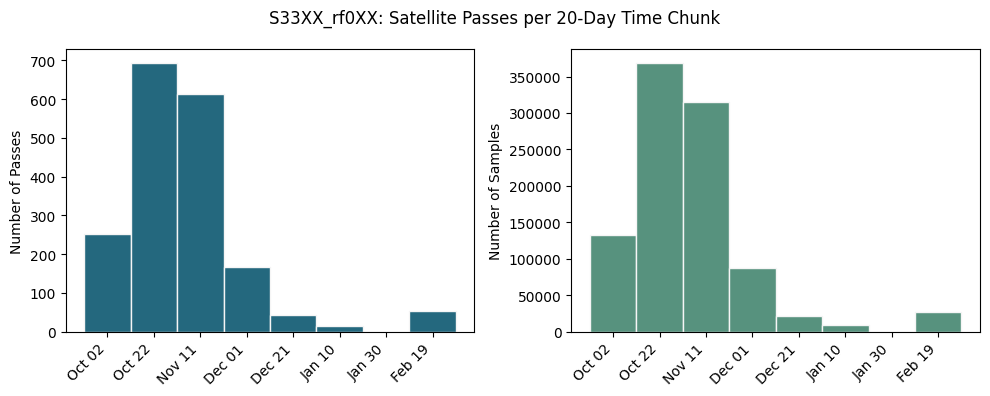

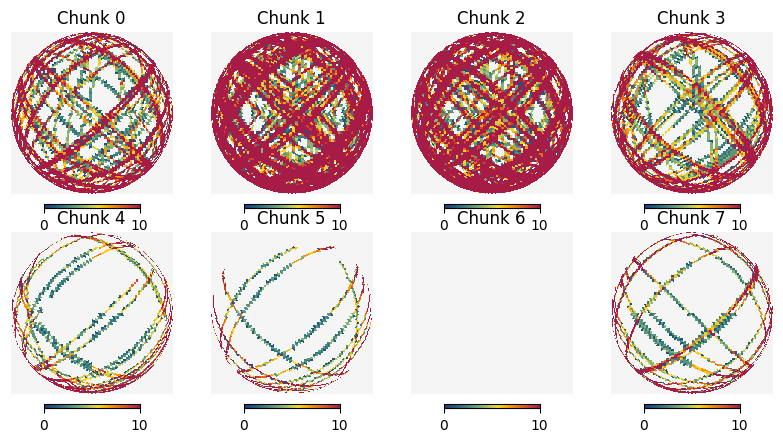

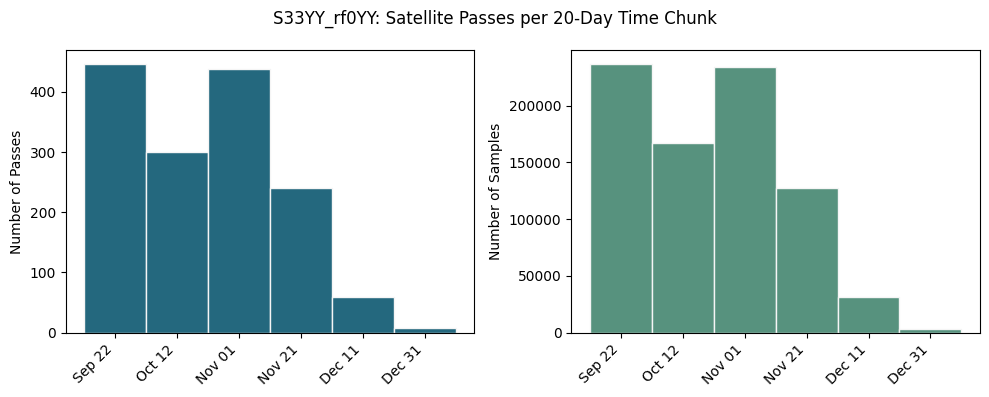

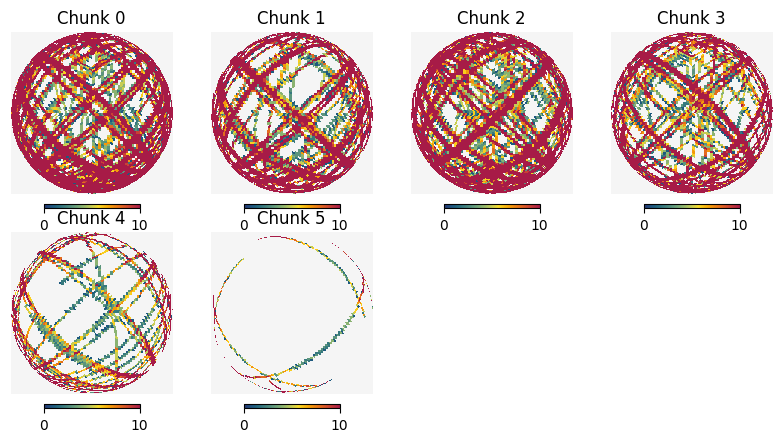

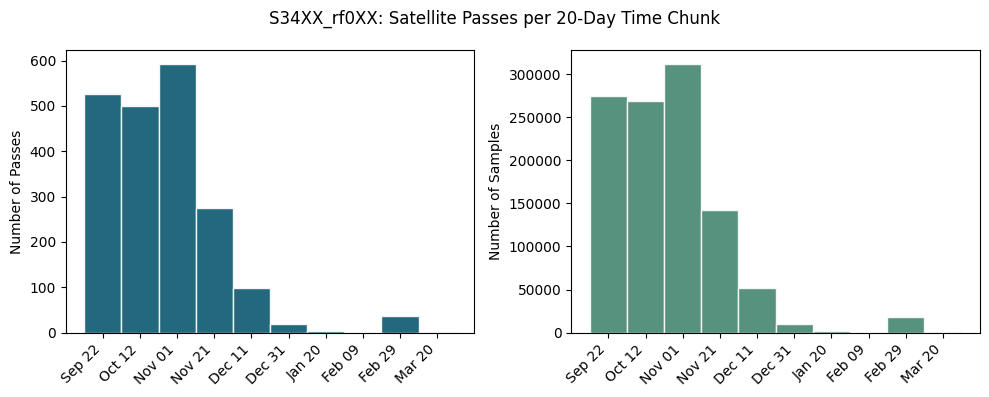

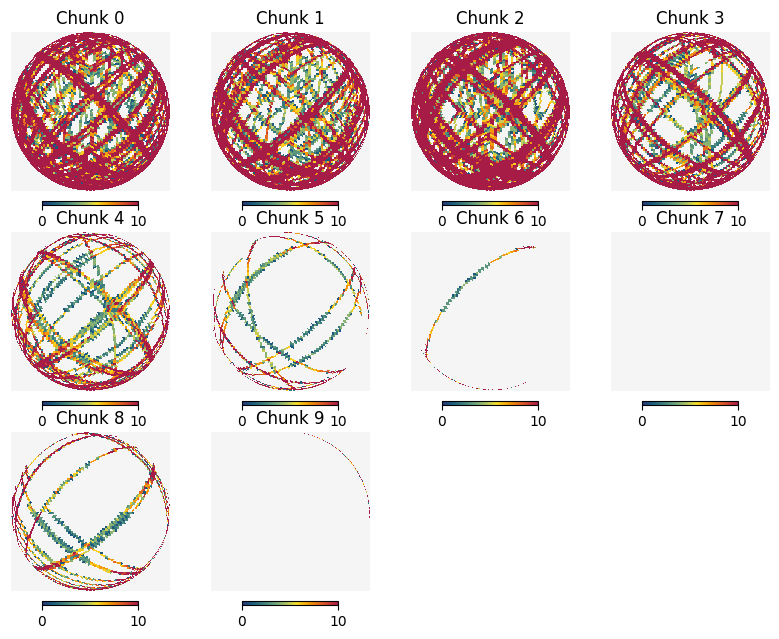

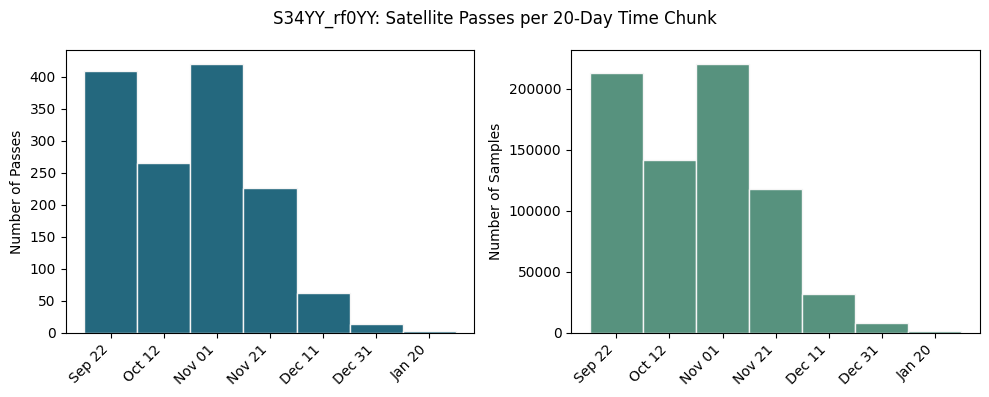

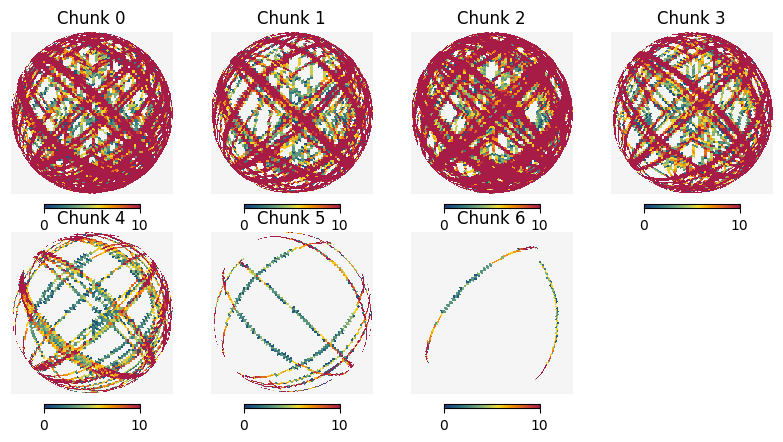

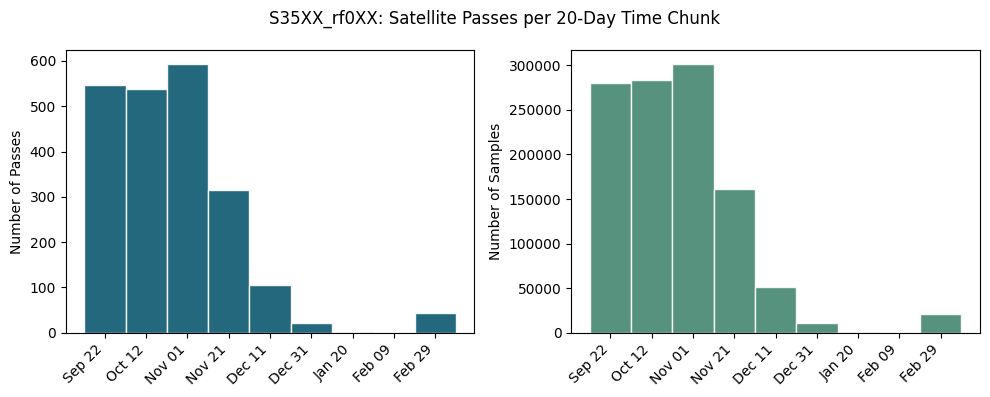

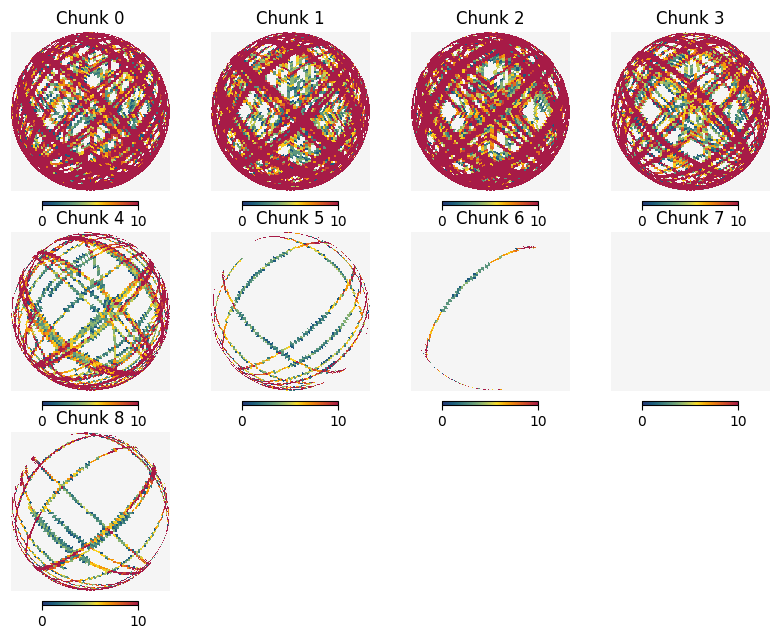

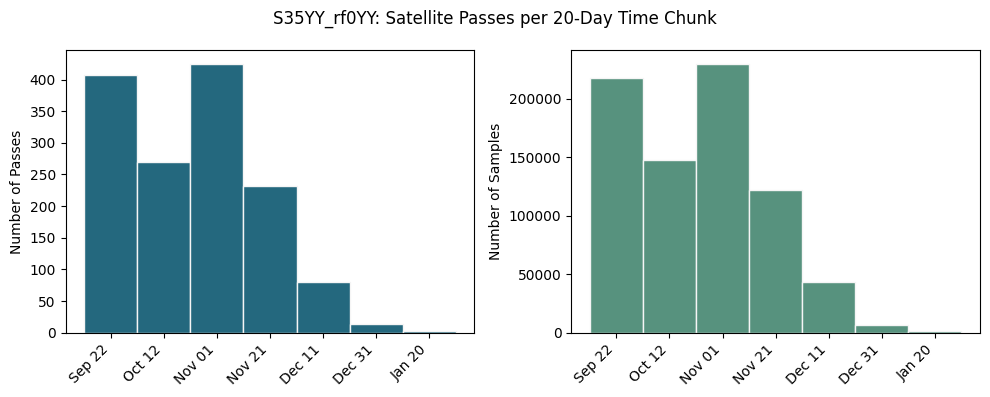

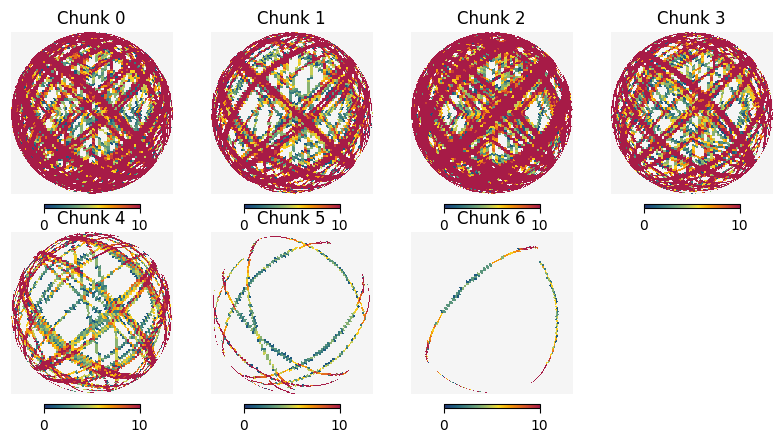

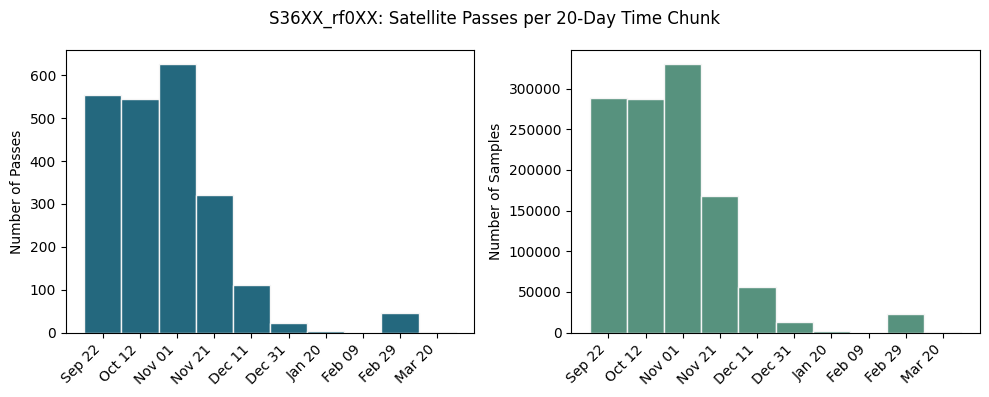

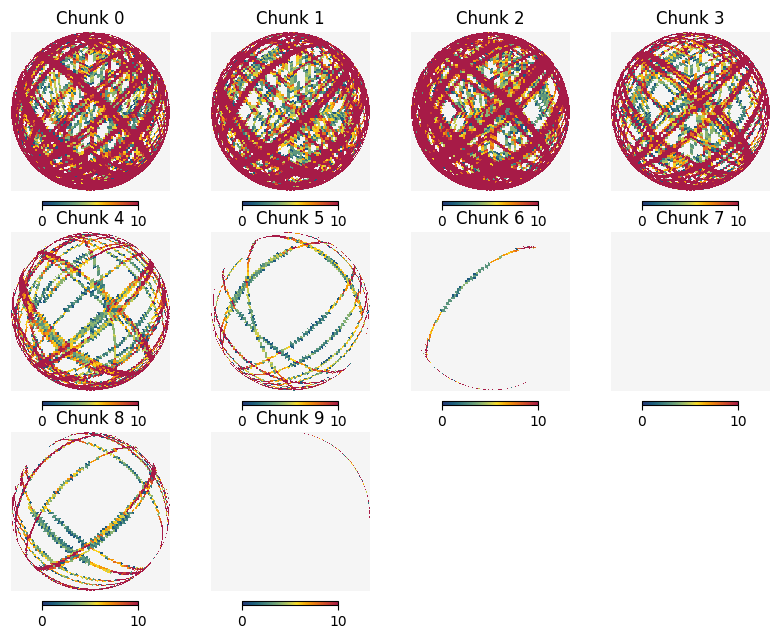

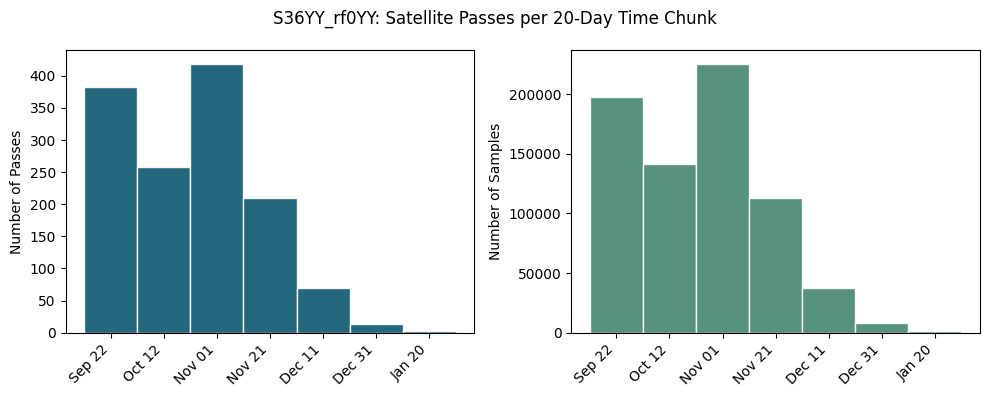

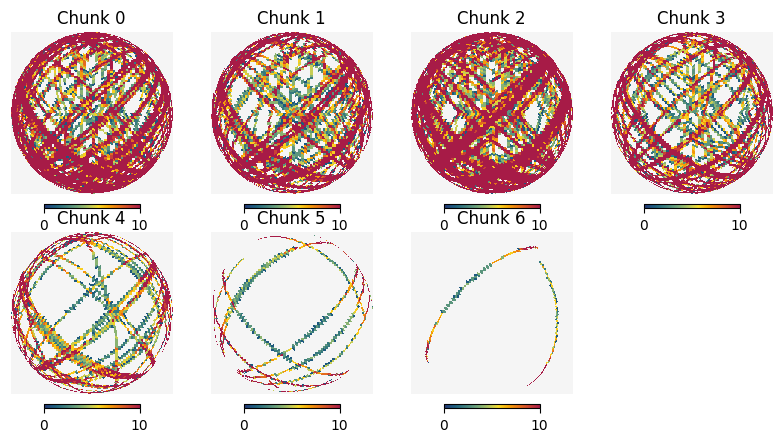

In [8]:
pfs = sorted(Path("../passes/monotonic_concave_cal/rf0/").glob("*.h5"))

for p in pfs:
    pf = PassFile(p)
    passes = pf.read_passes(pointing=0)
    
    chunk_days = 20
    chunk_sec = chunk_days * 24 * 60 * 60
    chunks, bin_edges, bin_centers = chunk_passes(
        passes,
        chunk_sec=chunk_sec,
    )
    
    pass_counts = [len(chunk) for chunk in chunks]
    
    sample_counts = [0]*len(chunks)
    for i, chunk in enumerate(chunks):
        for cid in chunk:
            pass_n_samples = passes[cid].power_db.size
            sample_counts[i] += pass_n_samples
    
    # Convert Unix timestamps to UTC datetimes
    bin_center_dt = [
        datetime.fromtimestamp(t, tz=UTC)
        for t in bin_centers
    ]
    
    median_maps, count_maps = chunks_to_healpix_counts(
        passes,
        chunks,
        decimate=1,
        nside=32,
    )

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    
    ax[0].bar(
        bin_center_dt,
        pass_counts,
        width=chunk_days,
        align="center",
        color=cmr.pride(0.2),
        ec="whitesmoke"
    )
    ax[0].set_ylabel("Number of Passes")
    
    ax[1].bar(
        bin_center_dt,
        sample_counts,
        width=chunk_days,
        align="center",
        color=cmr.pride(0.3),
        ec="whitesmoke"
    )
    ax[1].set_ylabel("Number of Samples")
    
    labels = [dt.strftime("%b %d") for dt in bin_center_dt]
    for a in ax:
        a.set_xticks(bin_center_dt)
        a.set_xticklabels(labels, rotation=45, ha="right")

    fig.suptitle(f"{p.stem[:11]}: Satellite Passes per {chunk_days}-Day Time Chunk")
    
    plt.tight_layout()
    plt.show()

    ncols = 4
    nrows = np.ceil(len(count_maps) / ncols)
    
    fig = plt.figure(figsize=(2 * ncols, 2 * nrows))
    
    for i, count_map in enumerate(count_maps):
        hp.orthview(
            count_map,
            fig=fig.number,
            sub=(nrows, ncols, i + 1),
            title=f"Chunk {i}",
            min=0,
            max=10,
            cmap=prd,
            cbar=True,
            half_sky=True,
            rot=(0, 90, 180)
        )
    
    plt.show()